<a href="https://colab.research.google.com/github/eshhha/Asteroid_diameter_prediction/blob/main/Asteroid_diameter_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


TensorFlow version: 2.20.0


#Read Dataset

In [3]:
filepath = '/content/drive/MyDrive/Exam/dataset.csv'
df_asteroid = pd.read_csv(filepath)
df_asteroid.head()

/tmp/ipykernel_3359/62193327.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asteroid = pd.read_csv(filepath)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#EDA

In [3]:
# Display all column names
print("\nColumn names:")
print(df_asteroid.columns.tolist())


Column names:
['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


In [4]:
df_asteroid.shape

(958524, 45)

In [5]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [6]:
df_asteroid.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [7]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [8]:
df_asteroid.duplicated().sum()

np.int64(0)

##PLOTS

In [4]:
num_cols = df_asteroid.select_dtypes(include=['int','float']).columns
cat_cols = df_asteroid.select_dtypes(include=['object','bool']).columns
num_cols


Index(['spkid', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch',
       'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad',
       'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e',
       'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma',
       'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms'],
      dtype='object')

In [5]:
cat_cols

Index(['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id',
       'equinox', 'class'],
      dtype='object')

In [ ]:
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(7,5,i+1)
  sns.histplot(df_asteroid[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [6]:
#outlier Detection
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(7,5,i+1)
  sns.boxplot(df_asteroid[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()



KeyboardInterrupt: 

Error in callback <function flush_figures at 0x78be92db1260> (for post_execute):


KeyboardInterrupt: 

In [7]:
correl_matrix = df_asteroid[num_cols].corr()
correl_matrix



,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
spkid,1.000000,0.146075,-0.095362,-0.179656,0.023419,0.006816,0.006816,0.006999,0.010951,0.000116,...,-0.000644,-0.000603,-0.000192,-0.000146,-0.000146,-0.000277,-0.000172,-0.000142,-0.000238,0.008187
H,0.146075,1.000000,-0.572648,-0.221658,-0.070651,-0.175712,-0.175712,-0.176349,0.345334,-0.032187,...,-0.033502,-0.029511,-0.004491,-0.006980,-0.006979,-0.013451,0.000111,-0.006806,-0.013075,0.005633
diameter,-0.095362,-0.572648,1.000000,-0.108880,0.337145,0.058475,0.058475,0.058539,-0.050649,0.146799,...,-0.019447,-0.017378,-0.024879,-0.009857,-0.009806,-0.023295,-0.025989,-0.009043,-0.022720,-0.182322
albedo,-0.179656,-0.221658,-0.108880,1.000000,-0.080525,0.094071,0.094071,0.094114,-0.020403,-0.114484,...,-0.033137,-0.029226,-0.041528,-0.020697,-0.020545,-0.039579,-0.041595,-0.017764,-0.039207,-0.217858
diameter_sigma,0.023419,-0.070651,0.337145,-0.080525,1.000000,-0.005169,-0.005169,-0.005120,-0.016542,0.206718,...,0.006477,0.007742,0.005930,0.005339,0.005510,0.006999,0.003722,0.006165,0.007724,0.044033
epoch,0.006816,-0.175712,0.058475,0.094071,-0.005169,1.000000,1.000000,0.999599,-0.098374,-0.004905,...,-0.062836,-0.068951,-0.025013,-0.013782,-0.013782,-0.027830,-0.029254,-0.013436,-0.024551,0.007472
epoch_mjd,0.006816,-0.175712,0.058475,0.094071,-0.005169,1.000000,1.000000,0.999599,-0.098374,-0.004905,...,-0.062836,-0.068951,-0.025013,-0.013782,-0.013782,-0.027830,-0.029254,-0.013436,-0.024551,0.007472
epoch_cal,0.006999,-0.176349,0.058539,0.094114,-0.005120,0.999599,0.999599,1.000000,-0.099691,-0.004919,...,-0.062907,-0.068721,-0.025095,-0.013816,-0.013815,-0.027630,-0.029088,-0.013470,-0.024424,0.007447
e,0.010951,0.345334,-0.050649,-0.020403,-0.016542,-0.098374,-0.098374,-0.099691,1.000000,0.014725,...,-0.006216,-0.000732,-0.000202,-0.002510,-0.002510,0.009128,0.000493,-0.002450,0.013446,-0.004903
a,0.000116,-0.032187,0.146799,-0.114484,0.206718,-0.004905,-0.004905,-0.004919,0.014725,1.000000,...,0.007018,0.006132,0.001080,0.001599,0.001599,0.036793,0.000087,0.001564,0.329317,-0.000485


Text(0.5, 1.0, 'Correlation heatmap')

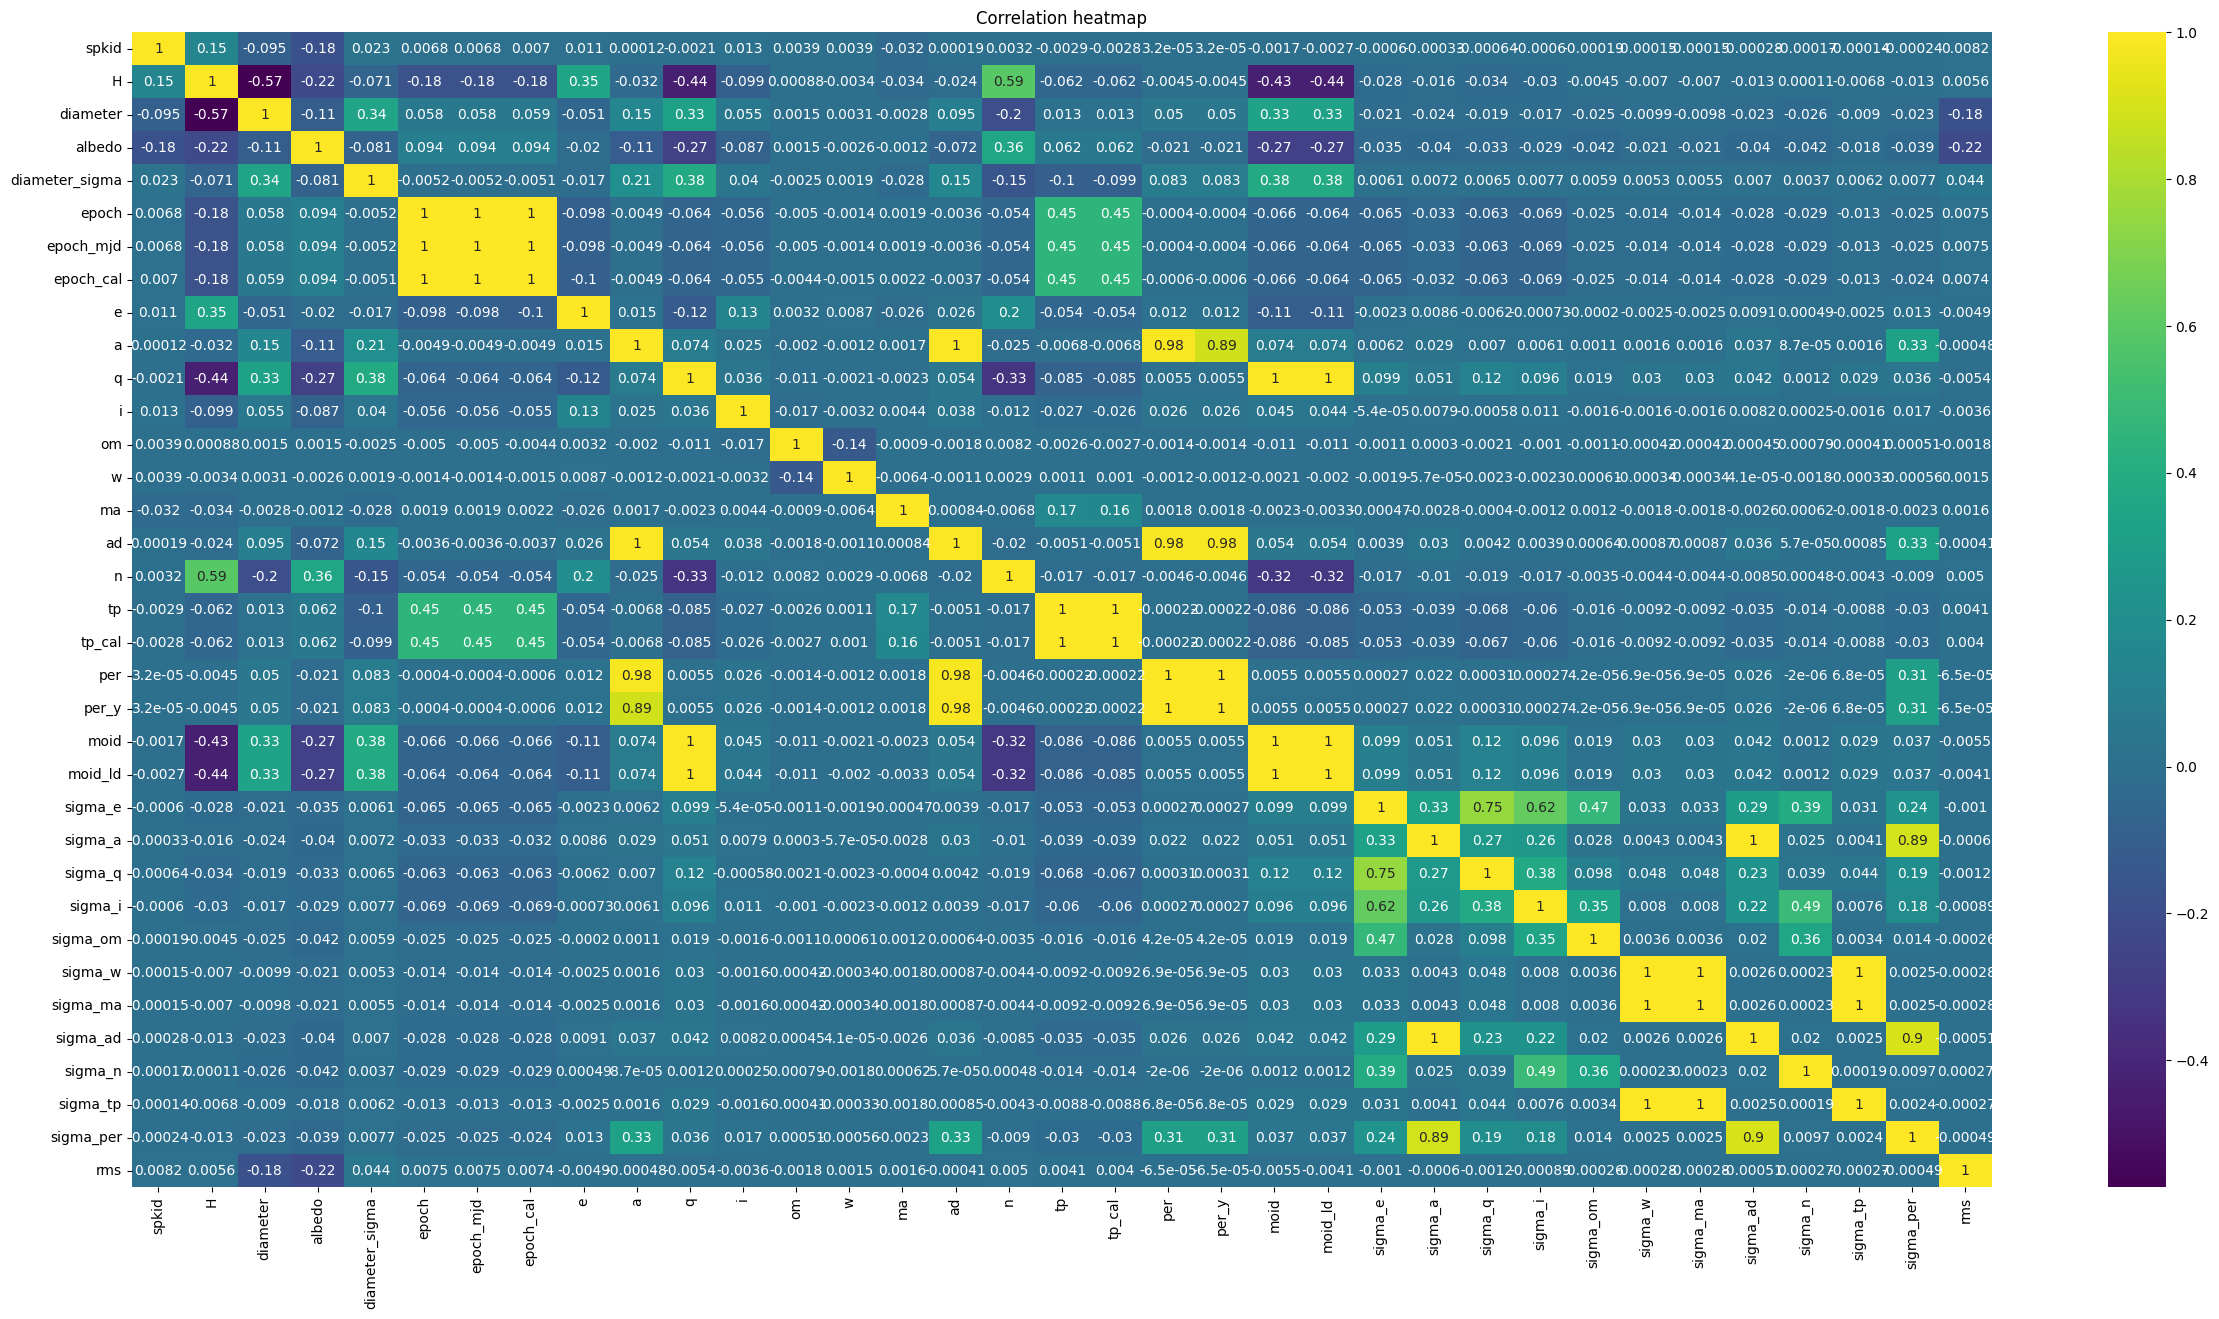

In [10]:
plt.figure(figsize =(30,15))
sns.heatmap(correl_matrix,annot = True,cmap = 'viridis',fmt = '.2g')
plt.title('Correlation heatmap')

#Data Preprocessing

In [12]:
TARGET = 'diameter'

##Encoding and Handling missing values

In [28]:
# Identify all columns that should be features (excluding identifiers) and the target.
# The TARGET column ('diameter') is included in 'data' at this stage.
exclude_cols = ['id', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id', 'equinox']
all_relevant_cols = [col for col in df_asteroid.columns if col not in exclude_cols]

# Create a copy containing all selected columns (features and target)
data = df_asteroid[all_relevant_cols].copy()

# Replace infinite values with NaN
data = data.replace([np.inf, -np.inf], np.nan)

# Identify numerical features for imputation (excluding TARGET)
numerical_cols_for_imputation = [col for col in data.columns if pd.api.types.is_numeric_dtype(data[col]) and col != TARGET]

# Fill missing numerical feature values using median
for column in numerical_cols_for_imputation:
    if data[column].isnull().any(): # Only impute if there are actual missing values
        data[column] = data[column].fillna(data[column].median())

# Identify categorical columns for imputation and encoding
categorical_cols_for_processing = ['neo', 'pha', 'class']

# Impute missing values in categorical columns with the mode
for col in categorical_cols_for_processing:
    if col in data.columns and data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

# Perform one-hot encoding on specified categorical columns
# Ensure these columns exist in the DataFrame before attempting to encode
cols_to_encode_existing = [col for col in categorical_cols_for_processing if col in data.columns]
if cols_to_encode_existing:
    data = pd.get_dummies(data, columns=cols_to_encode_existing, drop_first=True, dtype=int)

# Remove rows where the target ('diameter') is missing
data = data.dropna(subset=[TARGET])

print("Shape after preprocessing:", data.shape)
print("\nRemaining missing values after all processing:")
print(data.isnull().sum().sum()) # Should be 0
print("\nFirst 5 rows of the fully preprocessed data:")
data.head()

Shape after preprocessing: (136209, 49)

Remaining missing values after all processing:
0

First 5 rows of the fully preprocessed data:


,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2000001,3.40,939.400,0.0900,0.200,2458600.5,58600,20190427.0,0.076009,2.769165,...,0,0,0,0,0,1,0,0,0,0
1,2000002,4.20,545.000,0.1010,18.000,2459000.5,59000,20200531.0,0.229972,2.773841,...,0,0,0,0,0,1,0,0,0,0
2,2000003,5.33,246.596,0.2140,10.594,2459000.5,59000,20200531.0,0.256936,2.668285,...,0,0,0,0,0,1,0,0,0,0
3,2000004,3.00,525.400,0.4228,0.200,2458600.5,58600,20190427.0,0.088721,2.361418,...,0,0,0,0,0,1,0,0,0,0
4,2000005,6.90,106.699,0.2740,3.140,2459000.5,59000,20200531.0,0.190913,2.574037,...,0,0,0,0,0,1,0,0,0,0


In [27]:
data.head()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2000001,3.40,939.400,0.0900,0.200,2458600.5,58600,20190427.0,0.076009,2.769165,...,0,0,0,0,0,1,0,0,0,0
1,2000002,4.20,545.000,0.1010,18.000,2459000.5,59000,20200531.0,0.229972,2.773841,...,0,0,0,0,0,1,0,0,0,0
2,2000003,5.33,246.596,0.2140,10.594,2459000.5,59000,20200531.0,0.256936,2.668285,...,0,0,0,0,0,1,0,0,0,0
3,2000004,3.00,525.400,0.4228,0.200,2458600.5,58600,20190427.0,0.088721,2.361418,...,0,0,0,0,0,1,0,0,0,0
4,2000005,6.90,106.699,0.2740,3.140,2459000.5,59000,20200531.0,0.190913,2.574037,...,0,0,0,0,0,1,0,0,0,0


In [68]:
X = data.drop(columns=[TARGET])
y = data[TARGET]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame, retaining column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape of scaled features:", X_scaled_df.shape)
print("\nFirst 5 rows of scaled features:")
print(X_scaled.head())

Shape of scaled features: (136209, 48)

First 5 rows of scaled features:
      spkid         H    albedo  diameter_sigma    epoch  epoch_mjd  \
0 -0.439430 -8.418638 -0.365599       -0.356591 -0.43479   -0.43479   
1 -0.439429 -7.847222 -0.265572       22.389927  0.18209    0.18209   
2 -0.439427 -7.040097  0.761978       12.925842  0.18209    0.18209   
3 -0.439425 -8.704345  2.660673       -0.356591 -0.43479   -0.43479   
4 -0.439424 -5.918694  1.307580        3.400418  0.18209    0.18209   

   epoch_cal         e         a         q  ...  class_ATE  class_CEN  \
0  -0.390878 -0.899149 -0.033419  0.295116  ...  -0.026419  -0.019354   
1   0.182114  1.088407 -0.030293 -0.522692  ...  -0.026419  -0.019354   
2   0.182114  1.436495 -0.100853 -0.819114  ...  -0.026419  -0.019354   
3  -0.390878 -0.735040 -0.305981 -0.491789  ...  -0.026419  -0.019354   
4   0.182114  0.584184 -0.163854 -0.625831  ...  -0.026419  -0.019354   

   class_HYA  class_IEO  class_IMB  class_MBA  class_MCA  cla

In [69]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (108967, 48)
Shape of X_test: (27242, 48)
Shape of y_train: (108967,)
Shape of y_test: (27242,)


##Split the training data into training and validation

In [70]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 108967
Validation samples: 27242
Testing samples: 27242


##BUILD DEEP NEURAL NETWORK

In [72]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(
    input_size,
    learning_rate=0.001,
    dropout_rate=0.2
):

    # Create Sequential neural network
    model = Sequential()

    # Input layer + first hidden layer
    # Using input_shape directly in Dense for compatibility
    model.add(
        Dense(
            128,
            activation="relu",
            input_shape=(input_size,)
        )
    )

    # Dropout helps reduce overfitting
    model.add(
        Dropout(dropout_rate)
    )

    # Second hidden layer
    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    # Another dropout layer
    model.add(
        Dropout(dropout_rate)
    )

    # Third hidden layer
    model.add(
        Dense(
            32,
            activation="relu"
        )
    )

    # Output layer
    # One neuron because diameter is a continuous value
    model.add(
        Dense(
            1,
            activation="linear"
        )
    )

    # Create Adam optimizer
    optimizer = Adam(
        learning_rate=learning_rate
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

In [73]:
# Create the neural network
model = build_model(
    input_size=X_scaled_df.shape[1],
    learning_rate=0.001,
    dropout_rate=0.2
)

# Display architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 0 (0.00 B)

###Train the model

In [74]:
history = model.fit(
    X_train,
    y_train,

    # Validation data is used to monitor
    # generalization during training
    validation_data=(
        X_val,
        y_val
    ),

    # Number of training iterations
    epochs=50,

    # Number of samples processed at a time
    batch_size=32,

    # Display training progress
    verbose=1
)

Epoch 1/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 24.4775 - mae: 1.2528 - val_loss: 24.8022 - val_mae: 0.8451
Epoch 2/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 12.2682 - mae: 1.0226 - val_loss: 19.3067 - val_mae: 0.7351
Epoch 3/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 9.2297 - mae: 0.9629 - val_loss: 16.7933 - val_mae: 0.7172
Epoch 4/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 17.0285 - mae: 0.9550 - val_loss: 22.8876 - val_mae: 0.7922
Epoch 5/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 14.5104 - mae: 0.8706 - val_loss: 18.3824 - val_mae: 0.6684
Epoch 6/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 8.5141 - mae: 0.8578 - val_loss: 14.4602 - val_mae: 0.6151
Epoch 7/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 11.4226 - mae: 0.8369 - val_loss: 18.5744 - val_mae: 0.8878
Epoch 8/50
3406/3406 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 10.0287 - mae: 0.8386 - val_loss: 13.2441 - val_mae: 0.7485
Epoch 9/50
3406/3406 ━━━━

###TRAINING / VALIDATION LOSS

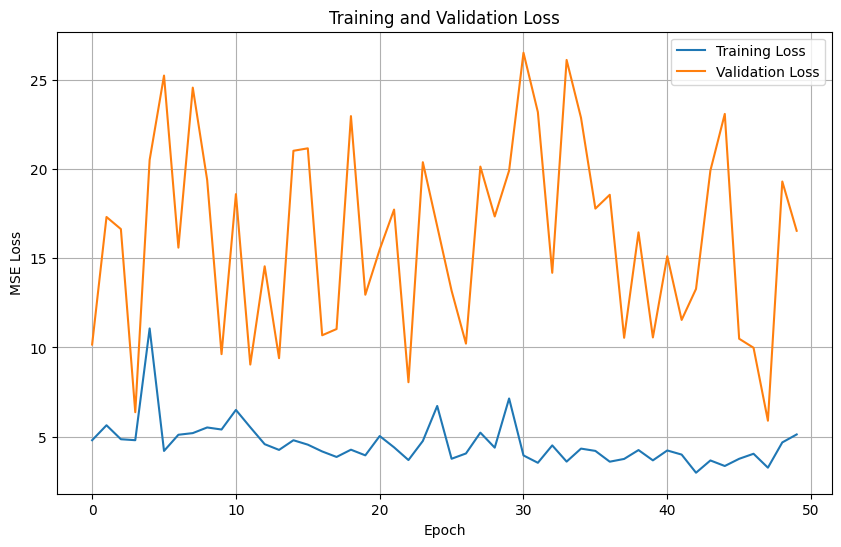

In [46]:

plt.figure(figsize=(10, 6))

# Training loss
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

# Validation loss
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

##HYPERPARAMETER TUNING

In [47]:
learning_rates = [
    0.001,
    0.0005,
    0.0001
]

dropout_rates = [
    0.1,
    0.2,
    0.3
]

In [78]:
print("X_scaled_df:", X_scaled_df.shape)
print("y:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_scaled_df: (136209, 48)
y_train: (108967,)
X_val: (27242, 48)
y_val: (27242,)


In [ ]:
results = []

for lr in learning_rates:

    for dropout in dropout_rates:

        print("\n====================================")
        print("Learning Rate:", lr)
        print("Dropout Rate:", dropout)
        print("====================================")

        # Create a new model
        temp_model = build_model(
            input_size=X_scaled_df.shape[1],
            learning_rate=lr,
            dropout_rate=dropout
        )

        # Train the model
        history = temp_model.fit(
            X_scaled_df,
            y,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=32,
            verbose=1
        )

        # Evaluate on validation data
        val_loss, val_mae = temp_model.evaluate(
            X_val,
            y_val,
            verbose=0
        )

        results.append({
            "learning_rate": lr,
            "dropout": dropout,
            "val_mae": val_mae
        })

        print("Validation MAE:", val_mae)


Learning Rate: 0.001
Dropout Rate: 0.1
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4257/4257 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 28.7005 - mae: 1.1689 - val_loss: 18.9636 - val_mae: 0.7205
Epoch 2/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 14.7964 - mae: 0.9232 - val_loss: 19.1047 - val_mae: 1.3712
Epoch 3/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 10.7361 - mae: 0.9249 - val_loss: 10.8440 - val_mae: 0.7697
Epoch 4/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 10.8094 - mae: 0.8737 - val_loss: 7.8550 - val_mae: 0.6259
Epoch 5/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 9.5129 - mae: 0.8308 - val_loss: 2.9098 - val_mae: 0.5959
Epoch 6/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 7.4987 - mae: 0.8052 - val_loss: 8.3974 - val_mae: 0.7071
Epoch 7/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 10.7169 - mae: 0.8237 - val_loss: 3.3866 - val_mae: 0.6331
Epoch 8/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 7.6422 - mae: 0.7888 - val_loss: 17.2773 - val_mae: 1.2775
Epoch 9/50
4257/4257 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4257/4257 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 30.9613 - mae: 1.3363 - val_loss: 21.1606 - val_mae: 0.7719
Epoch 2/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 14.7846 - mae: 1.0581 - val_loss: 18.4081 - val_mae: 0.8539
Epoch 3/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 11.5656 - mae: 0.9659 - val_loss: 13.4863 - val_mae: 0.7802
Epoch 4/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 11.4199 - mae: 0.9409 - val_loss: 10.2871 - val_mae: 0.7565
Epoch 5/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 11.7646 - mae: 0.8939 - val_loss: 7.8897 - val_mae: 0.7118
Epoch 6/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 12.7134 - mae: 0.8901 - val_loss: 9.2692 - val_mae: 0.8199
Epoch 7/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 12.6600 - mae: 0.8650 - val_loss: 9.3406 - val_mae: 0.8677
Epoch 8/50
4257/4257 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 8.1357 - mae: 0.8008 - val_loss: 7.4597 - val_mae: 0.9418
Epoch 9/50
4257/4257 ━━━━━━━━━━━

In [ ]:
# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort based on validation loss
results_df = results_df.sort_values(
    "best_validation_loss"
)

print(results_df)

In [ ]:
best_config = results_df.iloc[0]

print("Best configuration:")
print(best_config)

##Train final model using best hyperparameters

In [ ]:

best_learning_rate = float(
    best_config["learning_rate"]
)

best_dropout = float(
    best_config["dropout_rate"]
)

print("Best learning rate:", best_learning_rate)
print("Best dropout:", best_dropout)


final_model = build_model(
    input_size=X_train_scaled.shape[1],
    learning_rate=best_learning_rate,
    dropout_rate=best_dropout
)

final_model.summary()

# Train final model
final_history = final_model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,
    batch_size=32,

    verbose=1
)




###Plot final training and validation loss

In [ ]:


plt.figure(figsize=(10, 6))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Final Model Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

##Evaluate on test data

In [ ]:

test_loss, test_mae = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

##Calculate RMSE and R²

In [ ]:
# Generate predictions
y_pred = final_model.predict(
    X_test_scaled
).flatten()

# Mean Absolute Error
mae = mean_absolute_error(
    y_test,
    y_pred
)

# Mean Squared Error
mse = mean_squared_error(
    y_test,
    y_pred
)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R-squared score
r2 = r2_score(
    y_test,
    y_pred
)

print("================================")
print("MODEL PERFORMANCE")
print("================================")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

In [ ]:

# STEP 10: SAVE MODEL

final_model.save(
    "asteroid_diameter_model.keras"
)

print("Model saved successfully!")

In [ ]:

# Save the trained StandardScaler
joblib.dump(
    scaler,
    "asteroid_scaler.pkl"
)

print("Scaler saved successfully!")